# Building CNN from scratch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


# MNIST Dataset — Full Description and Usage

---

## What is MNIST?

The **MNIST (Modified National Institute of Standards and Technology)** dataset is a benchmark dataset for **handwritten digit recognition**.

It consists of grayscale images of digits from **0 to 9**, written by different people.

MNIST is widely used for:
- Teaching machine learning
- Benchmarking classification models
- Understanding neural networks and optimization

---

## Dataset Composition

### Total samples
- **70,000 images**

### Split
- **Training set:** 60,000 images
- **Test set:** 10,000 images

---

## Image Properties

Each image has:
- Height: **28 pixels**
- Width: **28 pixels**
- Channels: **1 (grayscale)**

Thus, each image is represented as:
$$
x \in \mathbb{R}^{28 \times 28}
$$

---

## Pixel Values

- Pixel intensities range from **0 to 255**
- Often normalized to:
$$
x \in [0, 1]
$$

Normalization:
```markdown
$$
x_{\text{norm}} = \frac{x}{255}
$$


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 468kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.37MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.7MB/s]


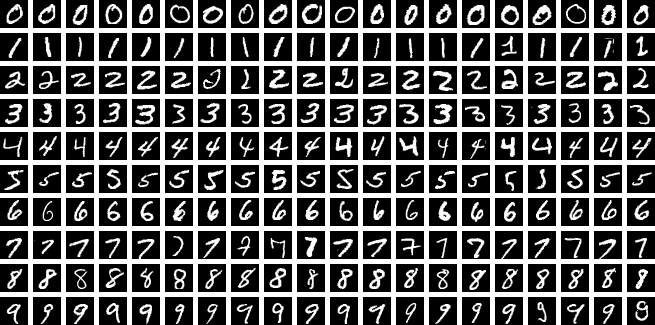

In [ ]:
print("\n=== Dataset Characteristics ===")
print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

sample_image, sample_label = train_dataset[0]
print("Image shape:", sample_image.shape)   # [1, 28, 28]
print("Label:", sample_label)
print("Number of classes:", len(train_dataset.classes))
print("Class names:", train_dataset.classes)



=== Dataset Characteristics ===
Training samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])
Label: 5
Number of classes: 10
Class names: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


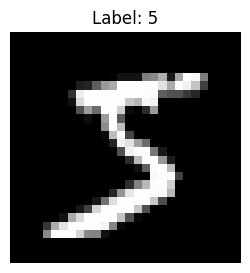

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


image, label = train_dataset[0]

plt.figure(figsize=(3, 3))
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()


### Let's try to solve it using an MLP

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten image
        return self.net(x)


In [ ]:
batch_size = 64
epochs = 5
learning_rate = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)

test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False
)

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [ ]:
def train(model):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        total_loss = 0
        correct_train = 0
        total_train = 0

        if epoch==0:
          model.eval()
          correct_test = 0
          total_test = 0
          with torch.no_grad():
              for images, labels in test_loader:
                  images, labels = images.to(device), labels.to(device)
                  outputs = model(images)
                  _, preds = torch.max(outputs, 1)
                  correct_test += (preds == labels).sum().item()
                  total_test += labels.size(0)
          test_acc = 100 * correct_test / total_test
          print(f"Epoch [{epoch}/{epochs}] "
                f"Test Acc: {test_acc:.2f}%")
          model.train()

        # ----- Training loop -----
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # Track train accuracy
            _, preds = torch.max(outputs, 1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)

        avg_loss = total_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train

        # ----- Evaluation on test set -----
        model.eval()
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                correct_test += (preds == labels).sum().item()
                total_test += labels.size(0)
        test_acc = 100 * correct_test / total_test

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Loss: {avg_loss:.4f} "
              f"Train Acc: {train_acc:.2f}% "
              f"Test Acc: {test_acc:.2f}%")

        model.train()  # back to training mode

In [ ]:
def evaluate(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total


In [ ]:
mlp = MLP().to(device)

print("=== MLP Model ===")
print("Trainable parameters:", f"{count_parameters(mlp):,}")

train(mlp)
mlp_accuracy = evaluate(mlp)

print(f"MLP Test Accuracy: {mlp_accuracy:.2f}%")


=== MLP Model ===
Trainable parameters: 235,146
Epoch [0/5] Test Acc: 4.97%
Epoch [1/5] Loss: 0.2292 Train Acc: 93.06% Test Acc: 96.98%
Epoch [2/5] Loss: 0.0929 Train Acc: 97.17% Test Acc: 97.27%
Epoch [3/5] Loss: 0.0648 Train Acc: 97.98% Test Acc: 97.72%
Epoch [4/5] Loss: 0.0476 Train Acc: 98.49% Test Acc: 97.95%
Epoch [5/5] Loss: 0.0396 Train Acc: 98.72% Test Acc: 97.65%
MLP Test Accuracy: 97.65%


### Now lets try a simple CNN.

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Convolution layers
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # Pooling
        self.pool = nn.MaxPool2d(2)

        # Activation
        self.relu = nn.ReLU()

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        # print("Input shape:", x.shape)          # [B, 1, 28, 28]

        x = self.conv1(x)
        x = self.relu(x)
        # print("After conv1:", x.shape)          # [B, 16, 28, 28]

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        # print("After conv2 + pool:", x.shape)   # [B, 32, 14, 14]

        x = self.conv3(x)
        x = self.relu(x)
        x = self.pool(x)
        # print("After conv3 + pool:", x.shape)   # [B, 64, 7, 7]

        x = x.view(x.size(0), -1)
        # print("After flatten:", x.shape)        # [B, 3136]

        x = self.fc1(x)
        x = self.relu(x)
        # print("After fc1:", x.shape)             # [B, 64]

        x = self.fc2(x)
        # print("Output shape:", x.shape)          # [B, 10]

        return x


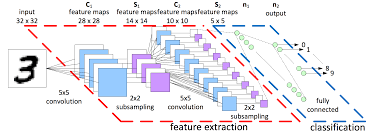

# Trainable Parameter Calculation

---

## General Formulas

### Convolution Layer
$$
\text{Parameters} = (\text{out_channels} \times \text{in_channels} \times k \times k) + \text{out_channels}
$$

### Fully Connected Layer
$$
\text{Parameters} = (\text{in_features} \times \text{out_features}) + \text{out_features} (bias)
$$

---

## Layer-wise Calculations

---

### Convolution Layer 1  
Input channels = 1, Output channels = 16, Kernel = $3 \times 3$

$$
(16 \times 1 \times 3 \times 3) + 16
$$

$$
= 144 + 16 = \boxed{160}
$$

---

### Convolution Layer 2  
Input channels = 16, Output channels = 32, Kernel = $3 \times 3$

$$
(32 \times 16 \times 3 \times 3) + 32
$$

$$
= 4608 + 32 = \boxed{4640}
$$

---

### Convolution Layer 3  
Input channels = 32, Output channels = 64, Kernel = $3 \times 3$

$$
(64 \times 32 \times 3 \times 3) + 64
$$

$$
= 18432 + 64 = \boxed{18496}
$$

---

### Fully Connected Layer 1  
Input features = $64 \times 7 \times 7 = 3136$, Output features = 64

$$
(3136 \times 64) + 64
$$

$$
= 200704 + 64 = \boxed{200768}
$$

---

### Fully Connected Layer 2  
Input features = 64, Output features = 10

$$
(64 \times 10) + 10
$$

$$
= 640 + 10 = \boxed{650}
$$

---

## Total Trainable Parameters

$$
160 + 4640 + 18496 + 200768 + 650
$$

$$
= \boxed{224{,}714}
$$


In [ ]:
cnn = SimpleCNN().to(device)

print("\n=== CNN Model ===")
print("Trainable parameters:", f"{count_parameters(cnn):,}")

train(cnn)
cnn_accuracy = evaluate(cnn)

print(f"CNN Test Accuracy: {cnn_accuracy:.2f}%")



=== CNN Model ===
Trainable parameters: 224,714
Epoch [0/5] Test Acc: 8.68%
Epoch [1/5] Loss: 0.1459 Train Acc: 95.42% Test Acc: 98.49%
Epoch [2/5] Loss: 0.0426 Train Acc: 98.68% Test Acc: 98.59%
Epoch [3/5] Loss: 0.0296 Train Acc: 99.07% Test Acc: 99.16%
Epoch [4/5] Loss: 0.0228 Train Acc: 99.28% Test Acc: 98.95%
Epoch [5/5] Loss: 0.0192 Train Acc: 99.36% Test Acc: 99.25%
CNN Test Accuracy: 99.25%


## RGB images

# CIFAR-10 Dataset

## Overview
CIFAR-10 is a widely used benchmark dataset for **image classification** tasks in machine learning and computer vision. It consists of small, color images categorized into **10 distinct classes**.

---

## Dataset Composition
- **Total images**: 60,000
- **Training images**: 50,000
- **Test images**: 10,000
- **Image size**: 32 × 32 pixels
- **Color channels**: 3 (RGB)

Each image is a low-resolution color image suitable for rapid experimentation and prototyping of convolutional neural networks (CNNs).

---

## Classes
The dataset contains exactly **10 classes**, each with 6,000 images:

| Class Index | Class Name |
|------------:|-----------|
| 0 | airplane |
| 1 | automobile |
| 2 | bird |
| 3 | cat |
| 4 | deer |
| 5 | dog |
| 6 | frog |
| 7 | horse |
| 8 | ship |
| 9 | truck |

---

## Data Distribution
- Training set: 5,000 images per class
- Test set: 1,000 images per class
- Class distribution is **balanced**

---

## Data Format
Each image is represented as:
\[
x \in \mathbb{R}^{32 \times 32 \times 3}
\]

Pixel values are typically stored as unsigned integers in the range:
\[
[0, 255]
\]

They are often normalized to:
\[
[0, 1] \quad \text{or} \quad [-1, 1]
\]

---

## Usage
CIFAR-10 is commonly used for:
- Image classification
- CNN architecture benchmarking
- Regularization and normalization studies
- Educational and research purposes

---

## Challenges
- Low spatial resolution
- High intra-class variation
- Visual similarity across certain classes (e.g., cat vs dog)

---

## Historical Context
- Introduced by **Alex Krizhevsky**, **Vinod Nair**, and **Geoffrey Hinton**
- Collected from the **80 Million Tiny Images** dataset
- Frequently used in early CNN research and modern deep learning benchmarks

---

## Variants
- **CIFAR-100**: 100 fine-grained classes with 600 images per class

---

## Summary
CIFAR-10 provides a compact, balanced, and standardized dataset that is ideal for evaluating image classification models under constrained input resolution.


In [ ]:
print("Dataset: CIFAR-10")
print("Image size: 32x32")
print("Channels: 3 (RGB)")
print("Number of classes: 10")


Dataset: CIFAR-10
Image size: 32x32
Channels: 3 (RGB)
Number of classes: 10


In [ ]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225))
])

train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 170M/170M [00:03<00:00, 43.8MB/s]


In [ ]:
print("\n=== Dataset Characteristics ===")
print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

image, label = train_dataset[0]
print("Single image shape:", image.shape)   # [3, 32, 32]
print("Label index:", label)
print("Class names:", train_dataset.classes)



=== Dataset Characteristics ===
Training samples: 50000
Test samples: 10000
Single image shape: torch.Size([3, 32, 32])
Label index: 6
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


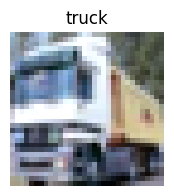

In [ ]:
def show_image(img, label):
    # Move to CPU and convert to float32
    img = img.cpu().float()

    # CHW → HWC
    img = img.permute(1, 2, 0)

    # Un-normalize properly (use the same device/dtype)
    mean = torch.tensor([0.4914, 0.4822, 0.4465])
    std  = torch.tensor([0.2470, 0.2435, 0.2616])

    img = img * std + mean
    img = img.clamp(0, 1)

    # Convert to numpy for matplotlib
    img = img.numpy()

    plt.figure(figsize=(2, 2))
    plt.imshow(img)
    plt.title(train_dataset.classes[label])
    plt.axis("off")
    plt.show()

# Example
image, label = train_dataset[1]
show_image(image, label)


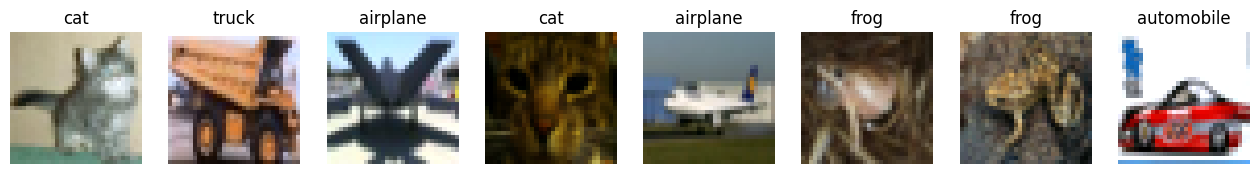

In [ ]:
import torch
import matplotlib.pyplot as plt

# Assume train_loader is already defined
# batch size in train_loader can be >= n

def show_batch(loader, n=8):
    images, labels = next(iter(loader))  # get one batch
    images, labels = images[:n], labels[:n]

    # Set up figure
    plt.figure(figsize=(2*n, 3))

    for i in range(n):
        # Convert from C,H,W to H,W,C for matplotlib
        img = images[i].permute(1, 2, 0)

        # Un-normalize the image
        mean = torch.tensor([0.4914, 0.4822, 0.4465])
        std  = torch.tensor([0.2470, 0.2435, 0.2616])
        img = img * std + mean
        img = img.clamp(0, 1)  # clip to valid range [0,1]

        # Plot
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(loader.dataset.classes[labels[i]])
        plt.axis("off")

    plt.show()

# Example usage
show_batch(train_loader, n=8)


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Convolution layers
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)  # [B, 3, 32, 32] -> [B, 16, 32, 32]
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # [B, 16, 32, 32] -> [B, 32, 32, 32]
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # [B, 32, 16, 16] -> [B, 64, 16, 16]

        self.pool = nn.MaxPool2d(2)  # halves spatial dimensions
        self.relu = nn.ReLU()

        #.  [B, 64, 8, 8]
        self.fc1 = nn.Linear(64*8*8, 256)  # Correct
        self.fc2 = nn.Linear(256, 10) # [B, 64] -> [B, 10] classes

    def forward(self, x):
        # x: [B, 3, 32, 32]
        x = self.relu(self.conv1(x))
        # After conv1: [B, 16, 32, 32]

        x = self.pool(self.relu(self.conv2(x)))
        # After conv2 + pool: [B, 32, 16, 16]

        x = self.pool(self.relu(self.conv3(x)))
        # After conv3 + pool: [B, 64, 8, 8]

        x = x.view(x.size(0), -1)
        # Flatten: [B, 64*8*8] = [B, 4096]

        x = self.relu(self.fc1(x))
        # After fc1: [B, 64]

        x = self.fc2(x)
        # Output: [B, 10] (logits for 10 classes)
        return x

[CNN Visualization](https://cs231n.github.io/convolutional-networks/)

In [ ]:
print("\n=== CNN Model ===")
epochs = 20
cnn = SimpleCNN().to(device)
print("Trainable parameters:", f"{count_parameters(cnn):,}")

train(cnn)
cnn_accuracy = evaluate(cnn)

print(f"CNN Test Accuracy: {cnn_accuracy:.2f}%")



=== CNN Model ===
Trainable parameters: 1,074,986
Epoch [0/20] Test Acc: 12.10%
Epoch [1/20] Loss: 1.2610 Train Acc: 55.12% Test Acc: 66.03%
Epoch [2/20] Loss: 0.8466 Train Acc: 70.41% Test Acc: 71.04%
Epoch [3/20] Loss: 0.6567 Train Acc: 76.94% Test Acc: 74.19%
Epoch [4/20] Loss: 0.5054 Train Acc: 82.45% Test Acc: 75.03%
Epoch [5/20] Loss: 0.3657 Train Acc: 87.28% Test Acc: 74.48%
Epoch [6/20] Loss: 0.2424 Train Acc: 91.60% Test Acc: 73.52%
Epoch [7/20] Loss: 0.1656 Train Acc: 94.19% Test Acc: 73.89%
Epoch [8/20] Loss: 0.1161 Train Acc: 95.94% Test Acc: 73.18%
Epoch [9/20] Loss: 0.0889 Train Acc: 96.92% Test Acc: 73.69%
Epoch [10/20] Loss: 0.0792 Train Acc: 97.28% Test Acc: 74.19%
Epoch [11/20] Loss: 0.0744 Train Acc: 97.49% Test Acc: 73.26%
Epoch [12/20] Loss: 0.0670 Train Acc: 97.70% Test Acc: 73.60%
Epoch [13/20] Loss: 0.0722 Train Acc: 97.53% Test Acc: 73.88%
Epoch [14/20] Loss: 0.0543 Train Acc: 98.18% Test Acc: 73.08%
Epoch [15/20] Loss: 0.0594 Train Acc: 98.02% Test Acc: 73.54

# Batch Normalization Formulation

Consider a mini-batch of activations for **one channel** (BatchNorm is applied independently per channel):

$$
\mathcal{B} = \{ x_1, x_2, \dots, x_m \}
$$

where $ m $ is the number of elements in the batch  
(for CNNs: $ m = B \times H \times W $).

---

## 1. Batch Mean
$$
\mu_{\mathcal{B}} = \frac{1}{m} \sum_{i=1}^{m} x_i
$$

---

## 2. Batch Variance
$$
\sigma_{\mathcal{B}}^2 = \frac{1}{m} \sum_{i=1}^{m} (x_i - \mu_{\mathcal{B}})^2
$$

---

## 3. Normalize
$$
\hat{x}_i = \frac{x_i - \mu_{\mathcal{B}}}{\sqrt{\sigma_{\mathcal{B}}^2 + \epsilon}}
$$

- $ \epsilon $ is a small constant for numerical stability

---

## 4. Scale and Shift (Learnable Parameters)
$$
y_i = \gamma \hat{x}_i + \beta
$$

- $ \gamma $: learnable scale parameter  
- $ \beta $: learnable shift parameter  

---

## 5. Final Output
$$
\boxed{
y_i = \gamma \frac{x_i - \mu_{\mathcal{B}}}{\sqrt{\sigma_{\mathcal{B}}^2 + \epsilon}} + \beta
}
$$

---

## 6. Inference (Test Time)

Instead of batch statistics, **running estimates** are used:

$$
\mu_{\text{running}}, \quad \sigma^2_{\text{running}}
$$

$$
y = \gamma \frac{x - \mu_{\text{running}}}{\sqrt{\sigma^2_{\text{running}} + \epsilon}} + \beta
$$



In [ ]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # -------------------
        # Convolution blocks
        # -------------------
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(64)

        self.pool  = nn.MaxPool2d(2)
        self.relu  = nn.ReLU()

        # Dropout for conv layers
        self.dropout_conv = nn.Dropout2d(0.25)

        # -------------------
        # Fully connected
        # -------------------
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)

        self.dropout_fc = nn.Dropout(0.5)

    def forward(self, x):
        # Block 1
        x = self.relu(self.bn1(self.conv1(x)))      # [B, 16, 32, 32]

        # Block 2
        x = self.pool(self.relu(self.bn2(self.conv2(x))))  # [B, 32, 16, 16]
        x = self.dropout_conv(x)

        # Block 3
        x = self.pool(self.relu(self.bn3(self.conv3(x))))  # [B, 64, 8, 8]
        x = self.dropout_conv(x)

        # Flatten
        x = x.view(x.size(0), -1)  # [B, 4096]

        # FC
        x = self.relu(self.fc1(x)) # [B, 256]
        x = self.dropout_fc(x)
        x = self.fc2(x)            # [B, 10]

        return x


In [ ]:
print("\n=== CNN Model ===")
epochs = 20
cnn = SimpleCNN().to("cuda")
print("Trainable parameters:", f"{count_parameters(cnn):,}")

train(cnn)
cnn_accuracy = evaluate(cnn)

print(f"CNN Test Accuracy: {cnn_accuracy:.2f}%")



=== CNN Model ===
Trainable parameters: 1,075,210
Epoch [0/20] Test Acc: 9.95%
Epoch [1/20] Loss: 1.7879 Train Acc: 34.09% Test Acc: 50.70%
Epoch [2/20] Loss: 1.5337 Train Acc: 43.99% Test Acc: 56.65%
Epoch [3/20] Loss: 1.4135 Train Acc: 49.05% Test Acc: 60.29%
Epoch [4/20] Loss: 1.3395 Train Acc: 51.68% Test Acc: 61.89%
Epoch [5/20] Loss: 1.2819 Train Acc: 53.91% Test Acc: 65.33%
Epoch [6/20] Loss: 1.2367 Train Acc: 55.71% Test Acc: 66.59%
Epoch [7/20] Loss: 1.1938 Train Acc: 57.10% Test Acc: 67.39%
Epoch [8/20] Loss: 1.1788 Train Acc: 57.83% Test Acc: 67.92%
Epoch [9/20] Loss: 1.1451 Train Acc: 59.27% Test Acc: 69.09%
Epoch [10/20] Loss: 1.1143 Train Acc: 60.36% Test Acc: 69.40%
Epoch [11/20] Loss: 1.1001 Train Acc: 60.85% Test Acc: 69.35%
Epoch [12/20] Loss: 1.0747 Train Acc: 61.58% Test Acc: 70.65%
Epoch [13/20] Loss: 1.0585 Train Acc: 62.41% Test Acc: 71.33%
Epoch [14/20] Loss: 1.0503 Train Acc: 62.78% Test Acc: 71.69%
Epoch [15/20] Loss: 1.0313 Train Acc: 63.50% Test Acc: 71.39%

## Transfer Learning

In [ ]:
from torchvision import models
device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------------
# Load pretrained ResNet18
# ---------------------------
resnet = models.resnet18(pretrained=True)

# ---------------------------
# Modify final layer for CIFAR-10
# ---------------------------
num_features = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 10)
)

# ---------------------------
# Freeze initial layers (optional)
# ---------------------------
for name, param in resnet.named_parameters():
    if "layer4" not in name and "fc" not in name:
        param.requires_grad = False  # freeze all except last block + fc

resnet = resnet.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Example usage:
print("Trainable parameters:", f"{count_parameters(resnet):,}")


Trainable parameters: 8,527,626


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, resnet.parameters()), lr=1e-3)
num_epochs = 20

In [ ]:
for epoch in range(num_epochs):
    resnet.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_acc = 100 * correct_train / total_train
    avg_loss = running_loss / len(train_loader)

    # Test accuracy
    resnet.eval()
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet(images)
            _, preds = torch.max(outputs, 1)
            correct_test += (preds == labels).sum().item()
            total_test += labels.size(0)
    test_acc = 100 * correct_test / total_test

    print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Loss: {avg_loss:.4f}, "
          f"Train Acc: {train_acc:.2f}%, "
          f"Test Acc: {test_acc:.2f}%")

Epoch [1/20], Loss: 1.1846, Train Acc: 60.44%, Test Acc: 68.08%
Epoch [2/20], Loss: 0.9252, Train Acc: 69.56%, Test Acc: 70.69%
Epoch [3/20], Loss: 0.8056, Train Acc: 72.96%, Test Acc: 70.55%
Epoch [4/20], Loss: 0.7137, Train Acc: 76.11%, Test Acc: 70.47%
Epoch [5/20], Loss: 0.6321, Train Acc: 78.99%, Test Acc: 71.33%
Epoch [6/20], Loss: 0.5558, Train Acc: 81.39%, Test Acc: 70.31%
Epoch [7/20], Loss: 0.4859, Train Acc: 83.81%, Test Acc: 71.35%
Epoch [8/20], Loss: 0.4352, Train Acc: 85.40%, Test Acc: 71.26%
Epoch [9/20], Loss: 0.3897, Train Acc: 87.18%, Test Acc: 71.03%
Epoch [10/20], Loss: 0.3378, Train Acc: 88.71%, Test Acc: 70.73%
Epoch [11/20], Loss: 0.3066, Train Acc: 90.01%, Test Acc: 70.49%
Epoch [12/20], Loss: 0.2849, Train Acc: 90.67%, Test Acc: 70.62%
Epoch [13/20], Loss: 0.2593, Train Acc: 91.37%, Test Acc: 70.64%
Epoch [14/20], Loss: 0.2458, Train Acc: 91.97%, Test Acc: 70.90%
Epoch [15/20], Loss: 0.2248, Train Acc: 92.69%, Test Acc: 70.34%
Epoch [16/20], Loss: 0.2080, Train